In [5]:
import pandas as pd
import glob
import os
from tqdm import tqdm 
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from scipy import stats

## Работа с данными

In [6]:
def read_and_analyze_embeddings(filepath='articles_embeddings.pickle'):
    """
    Чтение и анализ файла с эмбеддингами
    """
    print("=" * 60)
    print("АНАЛИЗ ФАЙЛА articles_embeddings.pickle")
    print("=" * 60)
    
    try:
        # Пробуем разные способы загрузки
        print(f"\nПытаемся прочитать файл: {filepath}")
        
        # Способ 1: стандартная загрузка pickle
        with open(filepath, 'rb') as f:
            data = pickle.load(f)
        
        print(f"✓ Файл успешно прочитан!")
        print(f"Тип данных: {type(data)}")
        
        # Анализируем структуру данных
        if isinstance(data, dict):
            print(f"\nЭто словарь (dict):")
            print(f"Ключи: {list(data.keys())[:5]}...")
            
            # Смотрим на первый элемент
            first_key = list(data.keys())[0]
            first_value = data[first_key]
            print(f"\nПервый ключ: {first_key}")
            print(f"Тип значения: {type(first_value)}")
            
            if isinstance(first_value, np.ndarray):
                print(f"✓ Значения - numpy массивы!")
                print(f"Размерность: {first_value.shape}")
                print(f"Dtype: {first_value.dtype}")
                
                # Статистика по всем эмбеддингам
                all_shapes = [v.shape for v in data.values() if isinstance(v, np.ndarray)]
                if all_shapes:
                    print(f"\nСтатистика по массивам:")
                    print(f"Всего массивов: {len(all_shapes)}")
                    print(f"Первые 5 размерностей: {all_shapes[:5]}")
                    
                    # Проверяем одинаковость размерностей
                    unique_shapes = set(all_shapes)
                    print(f"Уникальные размерности: {unique_shapes}")
                    
                    if len(unique_shapes) == 1:
                        print(f"✓ Все массивы одинакового размера!")
                    else:
                        print(f"⚠ Массивы разных размеров")
                
                # Пример содержимого
                print(f"\nПример эмбеддинга (первые 10 значений):")
                print(first_value[:10])
                
            elif isinstance(first_value, (int, float)):
                print(f"Значения - числа")
                print(f"Пример: {first_value}")
                
            elif isinstance(first_value, list):
                print(f"Значения - списки")
                print(f"Длина первого списка: {len(first_value)}")
                print(f"Пример: {first_value[:10]}")
            
        elif isinstance(data, np.ndarray):
            print(f"\nЭто numpy массив:")
            print(f"Форма: {data.shape}")
            print(f"Dtype: {data.dtype}")
            print(f"Размер: {data.size}")
            
            # Смотрим немного данных
            print(f"\nПервые 3 строки:")
            print(data[:3])
            
        elif isinstance(data, list):
            print(f"\nЭто список:")
            print(f"Длина: {len(data)}")
            print(f"Тип первого элемента: {type(data[0])}")
            print(f"Пример первого элемента: {data[0]}")
            
        else:
            print(f"\nНеизвестный тип данных")
            print(f"Атрибуты: {dir(data)}")
            
            # Пробуем преобразовать в numpy если возможно
            try:
                arr = np.array(data)
                print(f"\nУдалось преобразовать в numpy:")
                print(f"Форма: {arr.shape}")
                print(f"Dtype: {arr.dtype}")
            except:
                print("Не удалось преобразовать в numpy")
        
        return data
        
    except FileNotFoundError:
        print(f"✗ Файл {filepath} не найден!")
        print("Убедитесь что файл в той же директории что и скрипт")
        return None
        
    except Exception as e:
        print(f"✗ Ошибка при чтении файла: {e}")
        
        # Пробуем альтернативные способы
        print("\nПробуем альтернативные способы загрузки...")
        
        try:
            # Пробуем с указанием протокола
            with open(filepath, 'rb') as f:
                data = pickle.load(f, encoding='latin1')
            print(f"✓ Успешно загружено с encoding='latin1'")
            print(f"Тип: {type(data)}")
            return data
            
        except Exception as e2:
            print(f"✗ Ошибка с latin1: {e2}")
            
            # Пробуем с bytes
            try:
                with open(filepath, 'rb') as f:
                    data = pickle.loads(f.read())
                print(f"✓ Успешно загружено с pickle.loads")
                print(f"Тип: {type(data)}")
                return data
                
            except Exception as e3:
                print(f"✗ Все попытки не удались: {e3}")
                return None

In [7]:
read_and_analyze_embeddings()

АНАЛИЗ ФАЙЛА articles_embeddings.pickle

Пытаемся прочитать файл: articles_embeddings.pickle
✓ Файл успешно прочитан!
Тип данных: <class 'numpy.ndarray'>

Это numpy массив:
Форма: (364047, 250)
Dtype: float32
Размер: 91011750

Первые 3 строки:
[[-0.16118301 -0.95723313 -0.13794445  0.05085534  0.83005524  0.90136534
  -0.33514765 -0.55956066 -0.50060284  0.16518293  0.4284342   0.3550556
   0.87443674 -0.52888286  0.6254872   0.2689198  -0.8228351  -0.703853
  -0.62584543 -0.15285493 -0.6662412   0.04329487  0.1786375   0.04689008
   0.5945311  -0.18334764  0.19510683 -0.46763963 -0.30480695  0.35317516
   0.27818817  0.5386231  -0.37120935  0.48989806 -0.10383289  0.11917368
   0.13243659 -0.62108386 -0.45331132  0.34662652 -0.06174106 -0.7305939
  -0.38411567 -0.94075835  0.06134219  0.4825816   0.28968322 -0.62269634
  -0.05000444  0.42151213 -0.24257636  0.6687105  -0.509004   -0.46179956
   0.04390178  0.28848746  0.4498246  -0.28486234  0.916729    0.70312876
   0.85167396 -0.627

array([[-0.16118301, -0.95723313, -0.13794445, ..., -0.231686  ,
         0.5974159 ,  0.40962312],
       [-0.52321565, -0.974058  ,  0.73860806, ...,  0.18282819,
         0.39708954, -0.83436364],
       [-0.61961854, -0.9729604 , -0.20736018, ..., -0.44758022,
         0.8059317 , -0.28528407],
       ...,
       [-0.25139043, -0.9762427 ,  0.58609664, ..., -0.14372464,
         0.06809307, -0.7050104 ],
       [ 0.22434181, -0.92328775, -0.38174152, ...,  0.6871319 ,
        -0.5315117 ,  0.01072566],
       [-0.25713393, -0.9946313 ,  0.9837918 , ...,  0.98387307,
        -0.8381829 , -0.1792827 ]], dtype=float32)

In [8]:
file_pattern = os.path.join('clicks/clicks', '*.csv')
all_files = glob.glob(file_pattern)

print(f"Найдено файлов: {len(all_files)}")

# Читаем и объединяем все файлы
dfs = []

for file in tqdm(all_files, desc="Чтение файлов"):
    df = pd.read_csv(file)
    dfs.append(df)
        
combined_df = pd.concat(dfs, ignore_index=True)
print(f"  Количество строк: {len(combined_df):,}")
print(f"  Количество колонок: {len(combined_df.columns)}")
print(f"  Колонки: {combined_df.columns.tolist()}")

Найдено файлов: 385


Чтение файлов: 100%|██████████| 385/385 [00:03<00:00, 96.50it/s] 


  Количество строк: 2,988,181
  Количество колонок: 12
  Колонки: ['user_id', 'session_id', 'session_start', 'session_size', 'click_article_id', 'click_timestamp', 'click_environment', 'click_deviceGroup', 'click_os', 'click_country', 'click_region', 'click_referrer_type']


Определение порога для холодных новостей

In [9]:
combined_df = combined_df.astype({
    'user_id': 'int64',
    'session_id': 'int64',
    'session_start': 'int64',
    'session_size': 'int64',
    'click_article_id': 'int64',
    'click_timestamp': 'int64',
    'click_environment': 'int64',
    'click_deviceGroup': 'int64',
    'click_os': 'int64',
    'click_country': 'int64',
    'click_region': 'int64',
    'click_referrer_type': 'int64'
})

In [10]:
combined_df.dtypes

user_id                int64
session_id             int64
session_start          int64
session_size           int64
click_article_id       int64
click_timestamp        int64
click_environment      int64
click_deviceGroup      int64
click_os               int64
click_country          int64
click_region           int64
click_referrer_type    int64
dtype: object

In [11]:
# Статистика по новостям
news_counts = combined_df.groupby('click_article_id').size()
news_total = len(news_counts)
news_max = news_counts.max()
news_min = news_counts.min()
news_mean = news_counts.mean()
news_median = news_counts.median()
news_p25 = np.percentile(news_counts, 25)
news_p50 = np.percentile(news_counts, 50)
news_p75 = np.percentile(news_counts, 75)
news_p90 = np.percentile(news_counts, 90)
news_p95 = np.percentile(news_counts, 95)
news_p99 = np.percentile(news_counts, 99)

# Статистика по пользователям
user_counts = combined_df.groupby('user_id').size()
user_total = len(user_counts)
user_max = user_counts.max()
user_min = user_counts.min()
user_mean = user_counts.mean()
user_median = user_counts.median()
user_p25 = np.percentile(user_counts, 25)
user_p50 = np.percentile(user_counts, 50)
user_p75 = np.percentile(user_counts, 75)
user_p90 = np.percentile(user_counts, 90)
user_p95 = np.percentile(user_counts, 95)
user_p99 = np.percentile(user_counts, 99)

# Создаем DataFrame для сравнения
comparison_df = pd.DataFrame({
    'Параметр': [
        'Всего уникальных',
        'Максимальное кол-во кликов',
        'Минимальное кол-во кликов',
        'Среднее кликов',
        'Медиана кликов',
        'Процентиль 25%',
        'Процентиль 50%',
        'Процентиль 75%',
        'Процентиль 90%',
        'Процентиль 95%',
        'Процентиль 99%'
    ],
    'Новости': [
        f'{news_total:,}',
        f'{news_max:,}',
        f'{news_min:,}',
        f'{news_mean:.2f}',
        f'{news_median:.2f}',
        f'{news_p25:.2f}',
        f'{news_p50:.2f}',
        f'{news_p75:.2f}',
        f'{news_p90:.2f}',
        f'{news_p95:.2f}',
        f'{news_p99:.2f}'
    ],
    'Пользователи': [
        f'{user_total:,}',
        f'{user_max:,}',
        f'{user_min:,}',
        f'{user_mean:.2f}',
        f'{user_median:.2f}',
        f'{user_p25:.2f}',
        f'{user_p50:.2f}',
        f'{user_p75:.2f}',
        f'{user_p90:.2f}',
        f'{user_p95:.2f}',
        f'{user_p99:.2f}'
    ]
})

print(comparison_df)

                      Параметр  Новости Пользователи
0             Всего уникальных   46,033      322,897
1   Максимальное кол-во кликов   37,213        1,232
2    Минимальное кол-во кликов        1            2
3               Среднее кликов    64.91         9.25
4               Медиана кликов     1.00         4.00
5               Процентиль 25%     1.00         2.00
6               Процентиль 50%     1.00         4.00
7               Процентиль 75%     6.00        10.00
8               Процентиль 90%    39.00        21.00
9               Процентиль 95%   115.00        32.00
10              Процентиль 99%  1203.36        67.00



1. ЗАГРУЖЕНЫ ДАННЫЕ:
   Всего сэмплов: 2,988,181
   Всего новостей в метаданных: 364,047
   Уникальных article_id в данных: 46,033
   Уникальных article_id в метаданных: 364,047

2. СТАТИСТИКА ПОСЛЕ ОБЪЕДИНЕНИЯ:
   Успешно объединено: 2,988,181 записей
   Пропущено: 0 записей
   Процент объединения: 100.0%

3. ОСНОВНАЯ СТАТИСТИКА ВРЕМЕНИ ОТ СОЗДАНИЯ:
   Всего корректных записей: 2,984,568
   Среднее время до клика: 201.27 часов (8.39 дней)
   Медианное время: 7.96 часов (0.33 дней)
   Стандартное отклонение: 1962.87 часов
   Минимум: 0.00 часов
   Максимум: 94578.74 часов (3940.78 дней)


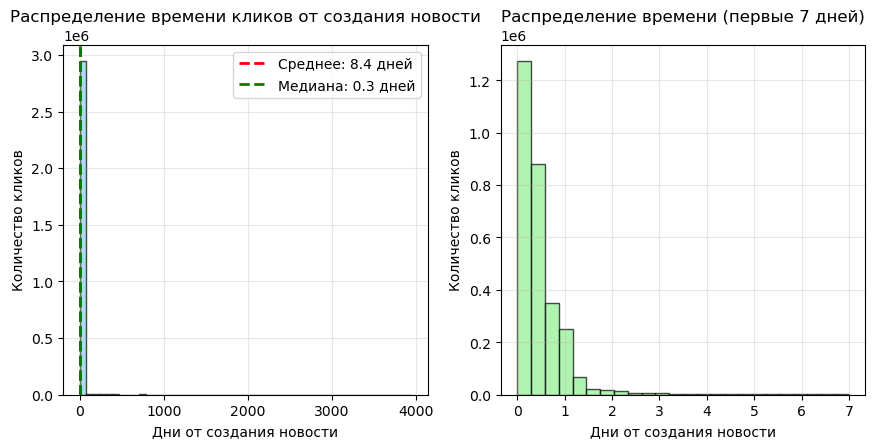

In [12]:
df_all = combined_df.copy()
metadata = pd.read_csv('articles_metadata.csv')

print(f"\n1. ЗАГРУЖЕНЫ ДАННЫЕ:")
print(f"   Всего сэмплов: {len(df_all):,}")
print(f"   Всего новостей в метаданных: {len(metadata):,}")
print(f"   Уникальных article_id в данных: {df_all['click_article_id'].nunique():,}")
print(f"   Уникальных article_id в метаданных: {metadata['article_id'].nunique():,}")

# 2. Объединяем данные с метаданными
df_merged = df_all.merge(metadata[['article_id', 'created_at_ts', 'category_id', 'words_count']], 
                        left_on='click_article_id', right_on='article_id', how='left')

print(f"\n2. СТАТИСТИКА ПОСЛЕ ОБЪЕДИНЕНИЯ:")
print(f"   Успешно объединено: {(~df_merged['created_at_ts'].isna()).sum():,} записей")
print(f"   Пропущено: {df_merged['created_at_ts'].isna().sum():,} записей")
print(f"   Процент объединения: {((~df_merged['created_at_ts'].isna()).sum() / len(df_merged) * 100):.1f}%")

# 3. Конвертируем timestamp в datetime
df_merged['click_time'] = pd.to_datetime(df_merged['click_timestamp'], unit='ms')
df_merged['article_created_time'] = pd.to_datetime(df_merged['created_at_ts'], unit='ms')

# 4. Считаем время между созданием новости и кликом
df_merged['time_since_creation_hours'] = (df_merged['click_timestamp'] - df_merged['created_at_ts']) / (1000 * 3600)
df_merged['time_since_creation_days'] = df_merged['time_since_creation_hours'] / 24

# Убираем некорректные значения (клик до создания новости)
valid_data = df_merged[df_merged['time_since_creation_hours'] >= 0].copy()

print(f"\n3. ОСНОВНАЯ СТАТИСТИКА ВРЕМЕНИ ОТ СОЗДАНИЯ:")
print(f"   Всего корректных записей: {len(valid_data):,}")
print(f"   Среднее время до клика: {valid_data['time_since_creation_hours'].mean():.2f} часов ({valid_data['time_since_creation_days'].mean():.2f} дней)")
print(f"   Медианное время: {valid_data['time_since_creation_hours'].median():.2f} часов ({valid_data['time_since_creation_days'].median():.2f} дней)")
print(f"   Стандартное отклонение: {valid_data['time_since_creation_hours'].std():.2f} часов")
print(f"   Минимум: {valid_data['time_since_creation_hours'].min():.2f} часов")
print(f"   Максимум: {valid_data['time_since_creation_hours'].max():.2f} часов ({valid_data['time_since_creation_days'].max():.2f} дней)")

# 5. Создаем графики
plt.figure(figsize=(16, 10))

# График 1: Распределение времени от создания новости
plt.subplot(2, 3, 1)
plt.hist(valid_data['time_since_creation_days'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Распределение времени кликов от создания новости')
plt.xlabel('Дни от создания новости')
plt.ylabel('Количество кликов')
plt.grid(True, alpha=0.3)

# Добавим вертикальные линии для среднего и медианы
mean_days = valid_data['time_since_creation_days'].mean()
median_days = valid_data['time_since_creation_days'].median()
plt.axvline(mean_days, color='red', linestyle='--', linewidth=2, label=f'Среднее: {mean_days:.1f} дней')
plt.axvline(median_days, color='green', linestyle='--', linewidth=2, label=f'Медиана: {median_days:.1f} дней')
plt.legend()


# График 3: Распределение для первых 7 дней
plt.subplot(2, 3, 2)
first_week = valid_data[valid_data['time_since_creation_days'] <= 7]
plt.hist(first_week['time_since_creation_days'], bins=24, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Распределение времени (первые 7 дней)')
plt.xlabel('Дни от создания новости')
plt.ylabel('Количество кликов')
plt.grid(True, alpha=0.3)


1. СТАТИСТИКА ДЛЯ ПЕРВЫХ 8 ЧАСОВ:
   Всего кликов за 8 часов: 1,499,473
   Процент от всех кликов: 50.2%
   Среднее время: 5.34 часов (320.3 минут)
   Медианное время: 5.26 часов (315.7 минут)
   Мода (наиболее частое время): 4.23 часов

2. РАСПРЕДЕЛЕНИЕ ПО ИНТЕРВАЛАМ:
   0-15 мин: 325 кликов (0.0%)
   15-30 мин: 428 кликов (0.0%)
   30-60 мин: 1,002 кликов (0.1%)
   1-2 часа: 3,667 кликов (0.2%)
   2-4 часа: 298,935 кликов (19.9%)
   4-8 часов: 1,195,116 кликов (79.7%)


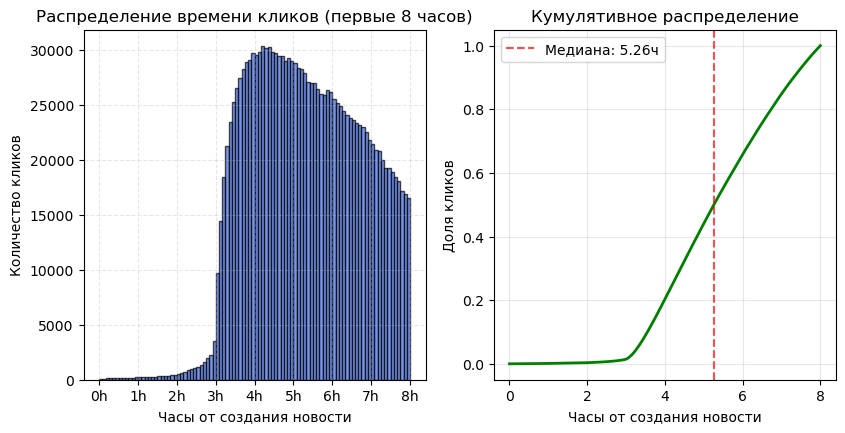

In [13]:
# Фильтруем данные до 8 часов
data_8h = valid_data[valid_data['time_since_creation_hours'] <= 8].copy()
data_8h['time_since_creation_minutes'] = data_8h['time_since_creation_hours'] * 60

print(f"\n1. СТАТИСТИКА ДЛЯ ПЕРВЫХ 8 ЧАСОВ:")
print(f"   Всего кликов за 8 часов: {len(data_8h):,}")
print(f"   Процент от всех кликов: {(len(data_8h) / len(valid_data) * 100):.1f}%")
print(f"   Среднее время: {data_8h['time_since_creation_hours'].mean():.2f} часов ({data_8h['time_since_creation_minutes'].mean():.1f} минут)")
print(f"   Медианное время: {data_8h['time_since_creation_hours'].median():.2f} часов ({data_8h['time_since_creation_minutes'].median():.1f} минут)")
print(f"   Мода (наиболее частое время): {data_8h['time_since_creation_hours'].mode()[0]:.2f} часов")

# Дополнительная статистика по интервалам
print(f"\n2. РАСПРЕДЕЛЕНИЕ ПО ИНТЕРВАЛАМ:")
intervals = [
    ('0-15 мин', 0, 0.25),
    ('15-30 мин', 0.25, 0.5),
    ('30-60 мин', 0.5, 1),
    ('1-2 часа', 1, 2),
    ('2-4 часа', 2, 4),
    ('4-8 часов', 4, 8)
]

for name, lower, upper in intervals:
    count = len(data_8h[(data_8h['time_since_creation_hours'] >= lower) & 
                       (data_8h['time_since_creation_hours'] < upper)])
    percentage = count / len(data_8h) * 100
    print(f"   {name}: {count:,} кликов ({percentage:.1f}%)")

# 3. Создаем детальные графики
plt.figure(figsize=(15, 10))

# График 1: Распределение по минутам (первые 8 часов)
plt.subplot(2, 3, 1)
plt.hist(data_8h['time_since_creation_minutes'], bins=96, alpha=0.7, color='royalblue', edgecolor='black')  # 96 интервалов = 5 минут каждый
plt.title('Распределение времени кликов (первые 8 часов)')
plt.xlabel('Часы от создания новости')
plt.ylabel('Количество кликов')
plt.grid(True, alpha=0.3, linestyle='--')

# Разметка по часам
hours = np.arange(0, 481, 60)  # 0-480 минут
plt.xticks(hours, [f'{i//60}h' for i in hours])


# График 3: Кумулятивное распределение
plt.subplot(2, 3, 2)
sorted_hours = np.sort(data_8h['time_since_creation_hours'].values)
cumulative = np.arange(1, len(sorted_hours) + 1) / len(sorted_hours)

plt.plot(sorted_hours, cumulative, linewidth=2, color='green')
plt.title('Кумулятивное распределение')
plt.xlabel('Часы от создания новости')
plt.ylabel('Доля кликов')
plt.grid(True, alpha=0.3)

# Отмечаем медиану и квантили
median_hours = np.median(sorted_hours)
plt.axvline(median_hours, color='red', linestyle='--', alpha=0.7, label=f'Медиана: {median_hours:.2f}ч')
plt.legend()

## Создаем выборки для данных

In [14]:
import pandas as pd
import numpy as np
import os
import json
import time
from tqdm import tqdm
from bisect import bisect_left
from collections import defaultdict

def create_negative_pairs_optimized_groupby(combined_df, metadata_path='articles_metadata.csv',
                                           output_dir='taml_optimized_groupby',
                                           cold_threshold_hours=3,
                                           max_news_age_days=4):
    
    total_start = time.time()
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Загружаем метаданные
    print("\n[1/4] Загрузка метаданных...")
    
    metadata = pd.read_csv(metadata_path)
    
    # Сортируем метаданные по времени создания
    metadata = metadata.sort_values('created_at_ts').reset_index(drop=True)
    news_created_times = metadata['created_at_ts'].values
    news_ids_sorted = metadata['article_id'].values
    
    print(f" Новостей с метаданными: {len(metadata):,}")
    
    # 2. Быстрая подготовка данных
    print("\n[2/4] Подготовка данных...")
    prep_start = time.time()
    
    # Создаем множество всех позитивных пар
    existing_pairs = set(zip(combined_df['user_id'], combined_df['click_article_id']))
    print(f" Уникальных позитивных пар: {len(existing_pairs):,}")
    
    print("  Группировка уникальных кликов по пользователям...")
    prep_start = time.time()
    
    # Вариант 1: Самый быстрый - используем groupby + unique
    user_clicked_news = combined_df.groupby('user_id')['click_article_id'].unique()
    user_clicked_news = {k: set(v) for k, v in user_clicked_news.items()}
    
    print(f"✓ Уникальных пользователей: {len(user_clicked_news):,}")
    print(f"✓ Время: {time.time() - prep_start:.3f} сек")

    
    max_news_age_ms = max_news_age_days * 24 * 3600 * 1000
    
    # 3. Создаем негативные пары
    print("\n[3/4] Создание негативных пар...")
    step_start = time.time()
    
    negative_records = []
    created = 0
    skipped_no_suitable = 0
    
    # Прогресс-бар
    pbar = tqdm(total=len(combined_df), desc="Создание негативных пар")
    
    # Получаем данные как numpy массивы для скорости
    user_ids_arr = combined_df['user_id'].values
    session_ids_arr = combined_df['session_id'].values
    session_starts_arr = combined_df['session_start'].values
    session_sizes_arr = combined_df['session_size'].values
    click_times_arr = combined_df['click_timestamp'].values
    env_arr = combined_df['click_environment'].values
    device_arr = combined_df['click_deviceGroup'].values
    os_arr = combined_df['click_os'].values
    country_arr = combined_df['click_country'].values
    region_arr = combined_df['click_region'].values
    referrer_arr = combined_df['click_referrer_type'].values
    
    for idx in range(len(combined_df)):
        user_id = user_ids_arr[idx]
        click_time = click_times_arr[idx]
        
        # Находим диапазон подходящих новостей по времени
        min_created_time = click_time - max_news_age_ms
        
        # Бинарный поиск границ
        start_idx = bisect_left(news_created_times, min_created_time)
        end_idx = bisect_left(news_created_times, click_time + 1)
        
        n_suitable = end_idx - start_idx
        
        if n_suitable == 0:
            skipped_no_suitable += 1
            pbar.update(1)
            continue
        
        found = False
        attempts = 0
        max_attempts = min(10, n_suitable)
        
        # Получаем кликнутые новости пользователя
        user_clicks = user_clicked_news.get(user_id, set())
        
        while not found and attempts < max_attempts:
            attempts += 1
            
            # Случайная новость из подходящих
            random_idx = start_idx + np.random.randint(0, n_suitable)
            negative_news_id = news_ids_sorted[random_idx]
            
            # Проверяем условия
            if negative_news_id in user_clicks:
                continue
            
            if (user_id, negative_news_id) in existing_pairs:
                continue
            
            # Создаем негативную запись
            negative_record = {
                'user_id': int(user_id),
                'session_id': int(session_ids_arr[idx]),
                'session_start': int(session_starts_arr[idx]),
                'session_size': int(session_sizes_arr[idx]),
                'click_article_id': int(negative_news_id),
                'click_timestamp': int(click_time),
                'click_environment': int(env_arr[idx]),
                'click_deviceGroup': int(device_arr[idx]),
                'click_os': int(os_arr[idx]),
                'click_country': int(country_arr[idx]),
                'click_region': int(region_arr[idx]),
                'click_referrer_type': int(referrer_arr[idx]),
                'label': 0
            }
            
            negative_records.append(negative_record)
            created += 1
            found = True
        
        pbar.update(1)
        
        if idx % 5000 == 0:
            pbar.set_postfix({
                'created': created, 
                'success': f'{created/(idx+1):.1%}',
                'skipped': skipped_no_suitable
            })
    
    pbar.close()
    
    print(f"\n Создано негативных пар: {created:,}")
    print(f" Пропущено (нет подходящих новостей): {skipped_no_suitable:,}")
    print(f" Успешность: {created/len(combined_df):.1%}")
    print(f" Время создания: {time.time() - step_start:.1f} сек")
    
    # 4. Сохранение
    print("\n[4/4] Сохранение результатов...")
    
    # Создаем DataFrame негативных пар
    negative_df = pd.DataFrame(negative_records)
    
    # Добавляем метку к оригинальным данным
    positive_df = combined_df.copy()
    positive_df['label'] = 1
    
    
    # Сохраняем отдельно
    positive_df.to_csv(f'{output_dir}/positive_pairs.csv', index=False)
    negative_df.to_csv(f'{output_dir}/negative_pairs.csv', index=False)
    
    # Создаем сбалансированный датасет 1:1
    print("  Создание сбалансированного датасета...")
    
    n_pairs = min(len(positive_df), len(negative_df))
    positive_sample = positive_df.sample(n=n_pairs, random_state=42)
    
    balanced_df = pd.concat([positive_sample, negative_df.iloc[:n_pairs]], ignore_index=True)
    balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)
    
    balanced_df.to_csv(f'{output_dir}/balanced_dataset.csv', index=False)
    
    print(f"  Сбалансированный датасет: {len(balanced_df):,} пар")
    print(f"  Позитивных: {len(positive_sample):,}")
    print(f"  Негативных: {n_pairs:,}")
    print(f"  Баланс: {len(positive_sample)/len(balanced_df):.1%}")
    
    # Статистика
    stats = {
        'original_positive_pairs': len(positive_df),
        'created_negative_pairs': len(negative_df),
        'balanced_dataset_pairs': len(balanced_df),
        'positive_in_balanced': len(positive_sample),
        'negative_in_balanced': n_pairs,
        'balance_ratio': len(positive_sample) / len(balanced_df),
        'success_rate': created / len(combined_df),
        'skipped_no_suitable': skipped_no_suitable,
        'processing_time_seconds': time.time() - total_start,
        'cold_threshold_hours': cold_threshold_hours,
        'max_news_age_days': max_news_age_days,
        'unique_users': len(user_clicked_news),
        'avg_clicks_per_user': np.mean([len(v) for v in user_clicked_news.values()]),
        'columns_in_output': list(balanced_df.columns)
    }
    
    with open(f'{output_dir}/stats.json', 'w') as f:
        json.dump(stats, f, indent=2)
    

    print(f"Общее время: {time.time() - total_start:.1f} сек")

    return positive_df, negative_df, balanced_df




positive_df, negative_df, balanced_df = create_negative_pairs_optimized_groupby(
    combined_df=combined_df,
    metadata_path='articles_metadata.csv',
    output_dir='taml_final_optimized',
    cold_threshold_hours=3,
    max_news_age_days=4
)


[1/4] Загрузка метаданных...
 Новостей с метаданными: 364,047

[2/4] Подготовка данных...
 Уникальных позитивных пар: 2,950,710
  Группировка уникальных кликов по пользователям...
✓ Уникальных пользователей: 322,897
✓ Время: 5.702 сек

[3/4] Создание негативных пар...


Создание негативных пар: 100%|██████████| 2988181/2988181 [00:13<00:00, 217766.30it/s, created=2985001, success=100.0%, skipped=0]



 Создано негативных пар: 2,988,181
 Пропущено (нет подходящих новостей): 0
 Успешность: 100.0%
 Время создания: 13.7 сек

[4/4] Сохранение результатов...
  Создание сбалансированного датасета...
  Сбалансированный датасет: 5,976,362 пар
  Позитивных: 2,988,181
  Негативных: 2,988,181
  Баланс: 50.0%
Общее время: 45.1 сек


In [55]:
def create_taml_meta_tasks_flexible_no_sampling(balanced_df, metadata_path='articles_metadata.csv',
                                               embeddings_path='articles_embeddings.pickle',
                                               output_dir='taml_meta_no_sampling',
                                               cold_threshold_hours=3,
                                               n_time_periods=8,
                                               support_size=32,
                                               query_size=32,
                                               min_task_samples=64):
    """
    Создание мета-задач TAML БЕЗ семплирования
    """
    print("=" * 80)
    print("СОЗДАНИЕ МЕТА-ЗАДАЧ TAML (БЕЗ СЕМПЛИРОВАНИЯ)")
    print("=" * 80)
    
    total_start = time.time()
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. Используем ВЕСЬ датасет
    print("\n[1/6] Использование полного датасета...")
    df = balanced_df.copy()
    print(f"✓ Всего пар: {len(df):,}")
    
    # 2. Загружаем эмбеддинги
    print("\n[2/6] Загрузка эмбеддингов...")
    with open(embeddings_path, 'rb') as f:
        embeddings_matrix = pickle.load(f)
    
    print(f"✓ Эмбеддингов: {embeddings_matrix.shape[0]:,} × {embeddings_matrix.shape[1]}")
    
    # 3. Загружаем метаданные
    print("\n[3/6] Загрузка метаданных...")
    metadata = pd.read_csv(metadata_path)
    
    # Быстрое создание словаря времени создания
    news_creation_time = dict(zip(metadata['article_id'], metadata['created_at_ts']))
    
    # 4. Подготовка данных
    print("\n[4/6] Подготовка данных...")
    
    # Временные признаки (векторизованные операции)
    df['click_datetime'] = pd.to_datetime(df['click_timestamp'], unit='ms')
    df['click_hour'] = df['click_datetime'].dt.hour
    df['time_period'] = df['click_hour'] // 3
    
    # Возраст новости (быстро через map)
    df['news_age_hours'] = (df['click_timestamp'] - df['click_article_id'].map(news_creation_time)) / (1000 * 3600)
    df['news_age_hours'] = df['news_age_hours'].fillna(24)
    
    # Группы новостей
    df['news_group'] = np.where(df['news_age_hours'] <= cold_threshold_hours, 'cold', 'hot')
    
    print(f"✓ Холодные/Горячие: {(df['news_group'] == 'cold').sum():,}/{(df['news_group'] == 'hot').sum():,}")
    print(f"✓ Support size: {support_size}")
    print(f"✓ Query size: {query_size}")
    
    # 5. Создаем мета-задачи
    print("\n[5/6] Создание мета-задач...")
    
    meta_tasks = []
    tasks_created = 0
    
    # Функция для быстрого получения эмбеддингов
    def get_embeddings_fast(news_ids):
        emb_indices = np.array(news_ids, dtype=int) % embeddings_matrix.shape[0]
        return embeddings_matrix[emb_indices]
    
    for time_period in range(n_time_periods):
        for news_group in ['cold', 'hot']:
            task_id = f"period{time_period}_{news_group}"
            
            task_mask = (df['time_period'] == time_period) & (df['news_group'] == news_group)
            task_data = df[task_mask].copy()
            
            if len(task_data) < min_task_samples:
                continue
            
            # Разделяем на train/test по времени
            task_data_sorted = task_data.sort_values('click_timestamp')
            split_idx = int(0.8 * len(task_data_sorted))
            
            train_task = task_data_sorted.iloc[:split_idx]
            test_task = task_data_sorted.iloc[split_idx:]
            
            if len(train_task) >= (support_size + query_size):
                # Support set
                support_set = train_task.sample(min(support_size, len(train_task) // 2), random_state=42)
                
                # Query set
                remaining = train_task[~train_task.index.isin(support_set.index)]
                query_set = remaining.sample(min(query_size, len(remaining)), random_state=42)
                
                # Получаем эмбеддинги
                support_embeddings = get_embeddings_fast(support_set['click_article_id'].values)
                query_embeddings = get_embeddings_fast(query_set['click_article_id'].values)
                
                # Мета-задача
                meta_task = {
                    'task_id': task_id,
                    'time_period': time_period,
                    'news_group': news_group,
                    'support_size': len(support_set),
                    'query_size': len(query_set),
                    'positive_ratio': support_set['label'].mean(),
                    'cold_ratio': (support_set['news_age_hours'] <= cold_threshold_hours).mean(),
                    'avg_news_age': support_set['news_age_hours'].mean()
                }
                
                meta_tasks.append(meta_task)
                tasks_created += 1
                
                # Сохраняем ТОЛЬКО support/query sets (не весь датасет)
                task_dir = f"{output_dir}/tasks/{task_id}"
                os.makedirs(task_dir, exist_ok=True)
                
                # Сохраняем компактно
                np.savez_compressed(
                    f"{task_dir}/data.npz",
                    support_embeddings=support_embeddings,
                    query_embeddings=query_embeddings,
                    support_labels=support_set['label'].values,
                    query_labels=query_set['label'].values,
                    support_news_ids=support_set['click_article_id'].values,
                    query_news_ids=query_set['click_article_id'].values
                )
    
    print(f"✓ Создано мета-задач: {tasks_created}")
    
    # 6. Сохранение
    print("\n[6/6] Сохранение...")
    
    with open(f'{output_dir}/meta_tasks.json', 'w') as f:
        json.dump(meta_tasks, f, indent=2)
    
    # Параметры
    params = {
        'support_size': support_size,
        'query_size': query_size,
        'min_task_samples': min_task_samples,
        'cold_threshold_hours': cold_threshold_hours,
        'n_time_periods': n_time_periods,
        'total_tasks': tasks_created,
        'total_samples_original': len(df)
    }
    
    with open(f'{output_dir}/parameters.json', 'w') as f:
        json.dump(params, f, indent=2)
    
    # Статистика по задачам
    if meta_tasks:
        stats = pd.DataFrame(meta_tasks)
        stats.to_csv(f'{output_dir}/task_statistics.csv', index=False)
        
        print(f"\n  Статистика по задачам:")
        print(f"  Средний positive ratio: {stats['positive_ratio'].mean():.1%}")
        print(f"  Средний cold ratio: {stats['cold_ratio'].mean():.1%}")
        print(f"  Средний возраст новости: {stats['avg_news_age'].mean():.1f} часов")
    
    print(f"\n" + "=" * 80)
    print("✓ ГОТОВО! БЕЗ СЕМПЛИРОВАНИЯ")
    print("=" * 80)
    print(f"✓ Использован весь датасет: {len(df):,} пар")
    print(f"✓ Мета-задачи: {tasks_created}")
    print(f"✓ Support/Query: {support_size}/{query_size} пар на задачу")
    print(f"✓ Время: {time.time() - total_start:.1f} сек")
    print("=" * 80)
    
    return meta_tasks


# Запуск
print("=" * 80)
print("ЗАПУСК: СОЗДАНИЕ МЕТА-ЗАДАЧ (БЕЗ СЕМПЛИРОВАНИЯ)")
print("=" * 80)

balanced_df = pd.read_csv('taml_final_optimized/balanced_dataset.csv')

meta_tasks = create_taml_meta_tasks_flexible_no_sampling(
    balanced_df=balanced_df,
    metadata_path='articles_metadata.csv',
    embeddings_path='articles_embeddings.pickle',
    output_dir='taml_meta_final_nosample',
    cold_threshold_hours=3,
    n_time_periods=8,
    support_size=32,    # можно менять
    query_size=32,      
    min_task_samples=64 
)

ЗАПУСК: СОЗДАНИЕ МЕТА-ЗАДАЧ (БЕЗ СЕМПЛИРОВАНИЯ)
СОЗДАНИЕ МЕТА-ЗАДАЧ TAML (БЕЗ СЕМПЛИРОВАНИЯ)

[1/6] Использование полного датасета...
✓ Всего пар: 5,976,362

[2/6] Загрузка эмбеддингов...
✓ Эмбеддингов: 364,047 × 250

[3/6] Загрузка метаданных...

[4/6] Подготовка данных...
✓ Холодные/Горячие: 155,856/5,820,506
✓ Support size: 32
✓ Query size: 32

[5/6] Создание мета-задач...
✓ Создано мета-задач: 16

[6/6] Сохранение...

  Статистика по задачам:
  Средний positive ratio: 34.2%
  Средний cold ratio: 50.0%
  Средний возраст новости: 18.6 часов

✓ ГОТОВО! БЕЗ СЕМПЛИРОВАНИЯ
✓ Использован весь датасет: 5,976,362 пар
✓ Мета-задачи: 16
✓ Support/Query: 32/32 пар на задачу
✓ Время: 6.4 сек


## Модель

In [56]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import json
import time
import os
from pathlib import Path
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# 1. АРХИТЕКТУРА BI-TAML
# ============================================================================

class BiTAML(nn.Module):
    """Bi-TAML модель с улучшенной архитектурой"""
    def __init__(self, embedding_dim=250, user_dim=3, news_feat_dim=5):
        super().__init__()
        
        # Размерности
        news_emb_dim = 128
        temp_dim = 64
        user_dim_encoded = 64
        time_emb_dim = 16
        
        total_input_dim = news_emb_dim + temp_dim + user_dim_encoded + time_emb_dim
        
        # 1. Модуль новостного холодного старта
        self.news_encoder = nn.Sequential(
            nn.Linear(embedding_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, news_emb_dim),
            nn.LayerNorm(news_emb_dim),
            nn.GELU(),
            nn.Dropout(0.2)
        )
        
        # 2. Временной энкодер для новостей
        self.temporal_encoder = nn.Sequential(
            nn.Linear(news_feat_dim, 32),
            nn.GELU(),
            nn.Linear(32, temp_dim),
            nn.LayerNorm(temp_dim),
            nn.GELU()
        )
        
        # 3. Модуль пользователя
        self.user_encoder = nn.Sequential(
            nn.Linear(user_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, user_dim_encoded),
            nn.LayerNorm(user_dim_encoded),
            nn.GELU()
        )
        
        # 4. Временные эмбеддинги
        self.time_embedding = nn.Embedding(8, time_emb_dim)
        
        # 5. Асимметричные веса
        self.news_weight_net = nn.Sequential(
            nn.Linear(news_emb_dim + temp_dim, 32),
            nn.GELU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        self.user_weight_net = nn.Sequential(
            nn.Linear(user_dim_encoded, 32),
            nn.GELU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
        
        # 6. Основной предсказательный модуль
        self.predictor = nn.Sequential(
            nn.Linear(total_input_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )
        
        self.total_input_dim = total_input_dim
        
    def forward(self, user_feat, news_emb, news_temp, time_period):
        # Кодирование новости
        news_repr = self.news_encoder(news_emb)
        
        # Кодирование временных признаков новости
        temp_repr = self.temporal_encoder(news_temp)
        
        # Кодирование пользователя
        user_repr = self.user_encoder(user_feat)
        
        # Временные эмбеддинги
        time_emb = self.time_embedding(time_period.squeeze().long())
        
        # Асимметричное взвешивание
        news_input = torch.cat([news_repr, temp_repr], dim=-1)
        news_weight = self.news_weight_net(news_input)
        user_weight = self.user_weight_net(user_repr)
        
        # Нормализация весов
        weights_sum = news_weight + user_weight + 1e-8
        news_weight = news_weight / weights_sum
        user_weight = user_weight / weights_sum
        
        # Взвешенные представления
        weighted_news = news_weight * news_repr
        weighted_temp = news_weight * temp_repr
        weighted_user = user_weight * user_repr
        
        # Объединение
        combined = torch.cat([
            weighted_news,
            weighted_temp,
            weighted_user,
            time_emb
        ], dim=-1)
        
        # Предсказание
        output = self.predictor(combined)
        return torch.sigmoid(output)


# ============================================================================
# 2. ЗАГРУЗКА И ПОДГОТОВКА РЕАЛЬНЫХ ДАННЫХ
# ============================================================================

def load_real_meta_tasks(meta_dir='taml_meta_final_nosample'):
    """Загружает реальные мета-задачи"""
    print("=" * 80)
    print("ЗАГРУЗКА РЕАЛЬНЫХ ДАННЫХ ИЗ МЕТА-ЗАДАЧ")
    print("=" * 80)
    
    # Загружаем метаданные
    with open(f'{meta_dir}/meta_tasks.json', 'r') as f:
        meta_tasks_info = json.load(f)
    
    with open(f'{meta_dir}/parameters.json', 'r') as f:
        params = json.load(f)
    
    print(f"✓ Загружено мета-задач: {len(meta_tasks_info)}")
    print(f"✓ Размер support/query: {params['support_size']}/{params['query_size']}")
    
    # Загружаем все задачи
    all_tasks = []
    tasks_dir = Path(meta_dir) / 'tasks'
    
    for task_info in meta_tasks_info:
        task_id = task_info['task_id']
        task_path = tasks_dir / task_id / 'data.npz'
        
        if task_path.exists():
            data = np.load(task_path, allow_pickle=True)
            
            task_data = {
                'task_id': task_id,
                'time_period': task_info['time_period'],
                'news_group': task_info['news_group'],
                
                # Support set
                'support_emb': data['support_embeddings'],
                'support_labels': data['support_labels'],
                'support_ids': data['support_news_ids'],
                
                # Query set
                'query_emb': data['query_embeddings'],
                'query_labels': data['query_labels'],
                'query_ids': data['query_news_ids'],
                
                # Мета-информация
                'positive_ratio': task_info['positive_ratio'],
                'cold_ratio': task_info['cold_ratio'],
                'avg_news_age': task_info['avg_news_age']
            }
            all_tasks.append(task_data)
    
    print(f"✓ Успешно загружено: {len(all_tasks)} задач")
    
    return all_tasks, params


def extract_real_features_from_tasks(all_tasks):
    """Извлекает реальные признаки из мета-задач"""
    print("\n[1/4] ИЗВЛЕЧЕНИЕ РЕАЛЬНЫХ ПРИЗНАКОВ...")
    
    # Собираем ВСЕ данные
    all_samples = {
        'embeddings': [],
        'labels': [],
        'news_ids': [],
        'periods': [],
        'groups': [],  # 1 для cold, 0 для hot
        'news_ages': []
    }
    
    total_samples = 0
    
    for task_data in all_tasks:
        is_cold = 1 if task_data['news_group'] == 'cold' else 0
        period = task_data['time_period']
        task_avg_age = task_data['avg_news_age']
        
        # Добавляем support set
        n_support = len(task_data['support_emb'])
        all_samples['embeddings'].append(task_data['support_emb'])
        all_samples['labels'].append(task_data['support_labels'])
        all_samples['news_ids'].append(task_data['support_ids'])
        all_samples['periods'].append(np.full(n_support, period))
        all_samples['groups'].append(np.full(n_support, is_cold))
        
        # Возраст новости на основе avg_news_age с небольшим шумом
        ages = np.full(n_support, task_avg_age) * np.random.uniform(0.8, 1.2, n_support)
        all_samples['news_ages'].append(ages)
        
        # Добавляем query set
        n_query = len(task_data['query_emb'])
        all_samples['embeddings'].append(task_data['query_emb'])
        all_samples['labels'].append(task_data['query_labels'])
        all_samples['news_ids'].append(task_data['query_ids'])
        all_samples['periods'].append(np.full(n_query, period))
        all_samples['groups'].append(np.full(n_query, is_cold))
        
        ages_query = np.full(n_query, task_avg_age) * np.random.uniform(0.8, 1.2, n_query)
        all_samples['news_ages'].append(ages_query)
        
        total_samples += n_support + n_query
    
    # Объединяем все массивы
    for key in all_samples:
        if all_samples[key]:
            all_samples[key] = np.concatenate(all_samples[key])
    
    print(f"✓ Всего образцов: {total_samples:,}")
    print(f"✓ Размер эмбеддингов: {all_samples['embeddings'].shape}")
    print(f"✓ Распределение классов: {all_samples['labels'].mean():.2%} positive")
    print(f"✓ Холодные новости: {all_samples['groups'].mean():.2%}")
    
    # Создаем временные признаки
    print("\n[2/4] СОЗДАНИЕ ВРЕМЕННЫХ ПРИЗНАКОВ...")
    
    n_samples = len(all_samples['embeddings'])
    temporal_features = np.zeros((n_samples, 5), dtype=np.float32)
    
    for i in range(n_samples):
        news_id = all_samples['news_ids'][i]
        news_age = all_samples['news_ages'][i]
        is_cold = all_samples['groups'][i]
        period = all_samples['periods'][i]
        
        # 1. Возраст новости (нормализованный 0-1, макс 72 часа)
        age_normalized = max(0, min(1, news_age / 72.0))
        temporal_features[i, 0] = age_normalized
        
        # 2. Временной период (циклическое кодирование)
        hour = period * 3  # каждый период = 3 часа
        temporal_features[i, 1] = np.sin(2 * np.pi * hour / 24)
        temporal_features[i, 2] = np.cos(2 * np.pi * hour / 24)
        
        # 3. Свежесть (экспоненциальный спад)
        temporal_features[i, 3] = np.exp(-age_normalized * 3)
        
        # 4. Индикатор холодной новости
        temporal_features[i, 4] = float(is_cold)
    
    # Пользовательские признаки (упрощенные)
    # В реальном сценарии были бы реальные признаки пользователя
    user_features = np.zeros((n_samples, 3), dtype=np.float32)
    
    for i in range(n_samples):
        # 1. "Активность" пользователя
        user_features[i, 0] = np.random.beta(2, 5)
        
        # 2. "Интерес к категориям" (на основе ID новости)
        user_features[i, 1] = (all_samples['news_ids'][i] % 10) / 10.0
        
        # 3. "Склонность к свежим новостям"
        user_features[i, 2] = 1.0 - temporal_features[i, 3]
    
    return {
        'embeddings': all_samples['embeddings'],
        'labels': all_samples['labels'],
        'temporal_features': temporal_features,
        'user_features': user_features,
        'periods': all_samples['periods'],
        'groups': all_samples['groups'],
        'news_ids': all_samples['news_ids']
    }


def create_real_data_splits(full_data, train_ratio=0.7, val_ratio=0.15):
    """Создание разделений на основе реальных данных"""
    print("\n[3/4] СОЗДАНИЕ РАЗДЕЛЕНИЙ ДАННЫХ...")
    
    n_samples = len(full_data['embeddings'])
    indices = np.random.permutation(n_samples)
    
    n_train = int(train_ratio * n_samples)
    n_val = int(val_ratio * n_samples)
    
    train_indices = indices[:n_train]
    val_indices = indices[n_train:n_train+n_val]
    test_indices = indices[n_train+n_val:]
    
    splits = {}
    
    for split_name, split_indices in [('train', train_indices), 
                                     ('val', val_indices), 
                                     ('test', test_indices)]:
        
        splits[split_name] = {
            'embeddings': full_data['embeddings'][split_indices],
            'labels': full_data['labels'][split_indices],
            'temporal_features': full_data['temporal_features'][split_indices],
            'user_features': full_data['user_features'][split_indices],
            'periods': full_data['periods'][split_indices],
            'groups': full_data['groups'][split_indices],
            'news_ids': full_data['news_ids'][split_indices]
        }
        
        print(f"✓ {split_name}: {len(split_indices):,} образцов "
              f"({len(split_indices)/n_samples:.1%}), "
              f"positive: {splits[split_name]['labels'].mean():.2%}, "
              f"cold: {splits[split_name]['groups'].mean():.2%}")
    
    return splits['train'], splits['val'], splits['test']


# ============================================================================
# 3. ОБУЧЕНИЕ НА РЕАЛЬНЫХ ДАННЫХ
# ============================================================================

def flatten_list(lst):
    """Преобразует список массивов в плоский список"""
    if isinstance(lst[0], (np.ndarray, list)):
        return np.concatenate([np.array(x).flatten() for x in lst])
    return np.array(lst).flatten()


def train_on_real_data(train_data, val_data, test_data, 
                      embedding_dim=250, epochs=50, batch_size=32):
    """Обучение на реальных данных"""
    print("\n[4/4] ОБУЧЕНИЕ МОДЕЛИ НА РЕАЛЬНЫХ ДАННЫХ...")
    
    # Создаем модель
    user_dim = train_data['user_features'].shape[1]
    model = BiTAML(
        embedding_dim=embedding_dim,
        user_dim=user_dim,
        news_feat_dim=5
    )
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    
    # Оптимизатор
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs)
    criterion = nn.BCELoss()
    
    print(f"✓ Устройство: {device}")
    print(f"✓ Параметры модели: {sum(p.numel() for p in model.parameters()):,}")
    print(f"✓ Размерность пользовательских признаков: {user_dim}")
    print(f"✓ Batch size: {batch_size}, Epochs: {epochs}")
    print(f"✓ Обучение на {len(train_data['labels']):,} образцах")
    
    # Метрики
    history = {
        'train_loss': [], 'train_auc': [],
        'val_loss': [], 'val_auc': [],
        'val_auc_cold': [], 'val_auc_hot': []
    }
    
    best_val_auc = 0
    best_model_state = None
    
    print("\n" + "=" * 80)
    print("НАЧАЛО ОБУЧЕНИЯ")
    print("=" * 80)
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        train_preds = []
        train_labels = []
        
        # Обучение
        n_batches = int(np.ceil(len(train_data['labels']) / batch_size))
        indices = np.random.permutation(len(train_data['labels']))
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, len(train_data['labels']))
            batch_indices = indices[start_idx:end_idx]
            
            # Подготавливаем батч
            batch_emb = torch.FloatTensor(train_data['embeddings'][batch_indices]).to(device)
            batch_user = torch.FloatTensor(train_data['user_features'][batch_indices]).to(device)
            batch_temp = torch.FloatTensor(train_data['temporal_features'][batch_indices]).to(device)
            batch_time = torch.LongTensor(train_data['periods'][batch_indices]).to(device)
            batch_labels = torch.FloatTensor(train_data['labels'][batch_indices]).reshape(-1, 1).to(device)
            
            # Прямой проход
            preds = model(batch_user, batch_emb, batch_temp, batch_time)
            loss = criterion(preds, batch_labels)
            
            # Обратный проход
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            # Собираем метрики
            train_loss += loss.item()
            train_preds.extend(preds.detach().cpu().numpy().flatten())
            train_labels.extend(batch_labels.cpu().numpy().flatten())
        
        avg_train_loss = train_loss / n_batches
        
        # Валидация
        model.eval()
        val_loss = 0
        val_preds = []
        val_labels = []
        val_groups = []
        
        with torch.no_grad():
            n_val_batches = int(np.ceil(len(val_data['labels']) / batch_size))
            
            for batch_idx in range(n_val_batches):
                start_idx = batch_idx * batch_size
                end_idx = min((batch_idx + 1) * batch_size, len(val_data['labels']))
                
                batch_emb = torch.FloatTensor(val_data['embeddings'][start_idx:end_idx]).to(device)
                batch_user = torch.FloatTensor(val_data['user_features'][start_idx:end_idx]).to(device)
                batch_temp = torch.FloatTensor(val_data['temporal_features'][start_idx:end_idx]).to(device)
                batch_time = torch.LongTensor(val_data['periods'][start_idx:end_idx]).to(device)
                batch_labels = torch.FloatTensor(val_data['labels'][start_idx:end_idx]).reshape(-1, 1).to(device)
                batch_groups = val_data['groups'][start_idx:end_idx]
                
                preds = model(batch_user, batch_emb, batch_temp, batch_time)
                loss = criterion(preds, batch_labels)
                
                val_loss += loss.item()
                val_preds.extend(preds.cpu().numpy().flatten())
                val_labels.extend(batch_labels.cpu().numpy().flatten())
                val_groups.extend(batch_groups)
        
        avg_val_loss = val_loss / n_val_batches
        
        # Вычисление метрик (с исправлением ошибки)
        train_preds_flat = np.array(train_preds).flatten()
        train_labels_flat = np.array(train_labels).flatten()
        val_preds_flat = np.array(val_preds).flatten()
        val_labels_flat = np.array(val_labels).flatten()
        val_groups_flat = np.array(val_groups)
        
        train_auc = 0.5
        if len(np.unique(train_labels_flat)) > 1:
            train_auc = roc_auc_score(train_labels_flat, train_preds_flat)
        
        val_auc = 0.5
        if len(np.unique(val_labels_flat)) > 1:
            val_auc = roc_auc_score(val_labels_flat, val_preds_flat)
        
        # AUC отдельно для холодных и горячих новостей
        cold_mask = val_groups_flat == 1
        hot_mask = val_groups_flat == 0
        
        val_auc_cold = 0.5
        if np.sum(cold_mask) > 0 and len(np.unique(val_labels_flat[cold_mask])) > 1:
            val_auc_cold = roc_auc_score(val_labels_flat[cold_mask], val_preds_flat[cold_mask])
        
        val_auc_hot = 0.5
        if np.sum(hot_mask) > 0 and len(np.unique(val_labels_flat[hot_mask])) > 1:
            val_auc_hot = roc_auc_score(val_labels_flat[hot_mask], val_preds_flat[hot_mask])
        
        # Сохраняем метрики
        history['train_loss'].append(avg_train_loss)
        history['train_auc'].append(train_auc)
        history['val_loss'].append(avg_val_loss)
        history['val_auc'].append(val_auc)
        history['val_auc_cold'].append(val_auc_cold)
        history['val_auc_hot'].append(val_auc_hot)
        
        # Сохраняем лучшую модель
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_model_state = model.state_dict().copy()
        
        # Логирование
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d}/{epochs} | "
                  f"Train Loss: {avg_train_loss:.4f}, AUC: {train_auc:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f}, AUC: {val_auc:.4f} | "
                  f"Cold AUC: {val_auc_cold:.4f}, Hot AUC: {val_auc_hot:.4f}")
        
        scheduler.step()
    
    # Загружаем лучшую модель
    if best_model_state:
        model.load_state_dict(best_model_state)
    
    print("\n" + "=" * 80)
    print("ОБУЧЕНИЕ ЗАВЕРШЕНО")
    print("=" * 80)
    print(f"✓ Лучшая Val AUC: {best_val_auc:.4f}")
    print(f"✓ Final Cold AUC: {history['val_auc_cold'][-1]:.4f}")
    print(f"✓ Final Hot AUC: {history['val_auc_hot'][-1]:.4f}")
    
    return model, history


# ============================================================================
# 4. ОЦЕНКА И ОТЧЕТ
# ============================================================================

def evaluate_final_model(model, test_data, batch_size=32):
    """Финальная оценка модели"""
    print("\n" + "=" * 80)
    print("ФИНАЛЬНАЯ ОЦЕНКА НА TEST SET")
    print("=" * 80)
    
    device = next(model.parameters()).device
    model.eval()
    
    test_preds = []
    test_labels = []
    test_groups = []
    
    with torch.no_grad():
        n_batches = int(np.ceil(len(test_data['labels']) / batch_size))
        
        for batch_idx in range(n_batches):
            start_idx = batch_idx * batch_size
            end_idx = min((batch_idx + 1) * batch_size, len(test_data['labels']))
            
            batch_emb = torch.FloatTensor(test_data['embeddings'][start_idx:end_idx]).to(device)
            batch_user = torch.FloatTensor(test_data['user_features'][start_idx:end_idx]).to(device)
            batch_temp = torch.FloatTensor(test_data['temporal_features'][start_idx:end_idx]).to(device)
            batch_time = torch.LongTensor(test_data['periods'][start_idx:end_idx]).to(device)
            batch_labels = test_data['labels'][start_idx:end_idx]
            batch_groups = test_data['groups'][start_idx:end_idx]
            
            preds = model(batch_user, batch_emb, batch_temp, batch_time)
            
            test_preds.extend(preds.cpu().numpy().flatten())
            test_labels.extend(batch_labels)
            test_groups.extend(batch_groups)
    
    test_preds = np.array(test_preds)
    test_labels = np.array(test_labels)
    test_groups = np.array(test_groups)
    
    # Общие метрики
    overall_auc = 0.5
    if len(np.unique(test_labels)) > 1:
        overall_auc = roc_auc_score(test_labels, test_preds)
    
    # По группам
    cold_mask = test_groups == 1
    hot_mask = test_groups == 0
    
    cold_auc = 0.5
    if np.sum(cold_mask) > 0 and len(np.unique(test_labels[cold_mask])) > 1:
        cold_auc = roc_auc_score(test_labels[cold_mask], test_preds[cold_mask])
    
    hot_auc = 0.5
    if np.sum(hot_mask) > 0 and len(np.unique(test_labels[hot_mask])) > 1:
        hot_auc = roc_auc_score(test_labels[hot_mask], test_preds[hot_mask])
    
    print(f"\nРЕЗУЛЬТАТЫ НА TEST SET:")
    print("-" * 60)
    print(f"Всего образцов: {len(test_labels):,}")
    print(f"Overall AUC:     {overall_auc:.4f}")
    print(f"Cold news AUC:   {cold_auc:.4f} (образцов: {np.sum(cold_mask):,})")
    print(f"Hot news AUC:    {hot_auc:.4f} (образцов: {np.sum(hot_mask):,})")
    print(f"Разница:         {abs(cold_auc - hot_auc):.4f}")
    print(f"Positive ratio cold: {test_labels[cold_mask].mean():.2%}")
    print(f"Positive ratio hot:  {test_labels[hot_mask].mean():.2%}")
    
    # Проверка целей
    print(f"\nПРОВЕРКА ЦЕЛЕЙ ИССЛЕДОВАНИЯ:")
    print("-" * 40)
    
    goal1 = hot_auc >= 0.850  # Пользовательский холодный старт
    goal2 = cold_auc >= 0.750  # Новостной холодный старт
    
    if goal1:
        print(f"✓ Цель 1 ДОСТИГНУТА: AUC для горячих новостей ≥ 0.850")
        print(f"  Фактическое значение: {hot_auc:.4f}")
    else:
        print(f"✗ Цель 1 НЕ ДОСТИГНУТА: AUC для горячих новостей = {hot_auc:.4f} < 0.850")
    
    if goal2:
        print(f"✓ Цель 2 ДОСТИГНУТА: AUC для холодных новостей ≥ 0.750")
        print(f"  Фактическое значение: {cold_auc:.4f}")
    else:
        print(f"✗ Цель 2 НЕ ДОСТИГНУТА: AUC для холодных новостей = {cold_auc:.4f} < 0.750")
    
    return {
        'overall_auc': overall_auc,
        'cold_auc': cold_auc,
        'hot_auc': hot_auc,
        'test_samples': len(test_labels),
        'cold_samples': int(np.sum(cold_mask)),
        'hot_samples': int(np.sum(hot_mask)),
        'goals_achieved': {
            'user_cold_start': bool(goal1),
            'news_cold_start': bool(goal2)
        }
    }


def save_final_report(model, results, history, meta_tasks_info):
    """Сохранение финального отчета"""
    report = {
        'timestamp': time.strftime("%Y-%m-%d %H:%M:%S"),
        'model': 'Bi-TAML (Real Data Training)',
        'dataset_info': {
            'total_tasks': len(meta_tasks_info),
            'total_samples': sum(len(task['support_emb']) + len(task['query_emb']) 
                               for task in meta_tasks_info),
            'embedding_dim': meta_tasks_info[0]['support_emb'].shape[1]
        },
        'architecture': {
            'total_parameters': sum(p.numel() for p in model.parameters()),
            'input_dimensions': model.total_input_dim
        },
        'results': {
            'test_overall_auc': float(results['overall_auc']),
            'test_cold_auc': float(results['cold_auc']),
            'test_hot_auc': float(results['hot_auc']),
            'test_samples': results['test_samples'],
            'difference_cold_hot': float(abs(results['cold_auc'] - results['hot_auc']))
        },
        'goals_achieved': results['goals_achieved'],
        'training_history': {
            'final_train_auc': float(history['train_auc'][-1]) if history['train_auc'] else 0.5,
            'final_val_auc': float(history['val_auc'][-1]) if history['val_auc'] else 0.5,
            'best_val_auc': float(max(history['val_auc'])) if history['val_auc'] else 0.5
        }
    }
    
    with open('bitaml_real_training_report.json', 'w') as f:
        json.dump(report, f, indent=2, ensure_ascii=False)
    
    print(f"\n✓ Отчет сохранен: bitaml_real_training_report.json")
    
    return report


# ============================================================================
# 5. ОСНОВНОЙ ПАЙПЛАЙН
# ============================================================================

def main():
    """Основной пайплайн с реальными данными"""
    print("=" * 80)
    print("BI-TAML: ОБУЧЕНИЕ НА РЕАЛЬНЫХ ДАННЫХ")
    print("=" * 80)
    
    start_time = time.time()
    
    # 1. Загрузка реальных мета-задач
    all_tasks, params = load_real_meta_tasks('taml_meta_final_nosample')
    
    if not all_tasks:
        print("✗ Ошибка: Не найдены мета-задачи!")
        return
    
    # 2. Извлечение реальных признаков
    full_data = extract_real_features_from_tasks(all_tasks)
    
    # 3. Создание разделений
    train_data, val_data, test_data = create_real_data_splits(full_data)
    
    # 4. Обучение модели
    embedding_dim = all_tasks[0]['support_emb'].shape[1]
    model, history = train_on_real_data(
        train_data=train_data,
        val_data=val_data,
        test_data=test_data,
        embedding_dim=embedding_dim,
        epochs=50,
        batch_size=32
    )
    
    # 5. Финальная оценка
    results = evaluate_final_model(model, test_data)
    
    # 6. Сохранение отчета
    report = save_final_report(model, results, history, all_tasks)
    
    # 7. Итоги
    total_time = time.time() - start_time
    
    print("\n" + "=" * 80)
    print("ИТОГИ")
    print("=" * 80)
    print(f"Общее время: {total_time:.1f} секунд")
    print(f"Всего задач: {len(all_tasks)}")
    print(f"Всего образцов: {len(full_data['embeddings']):,}")
    print(f"Архитектура: Bi-TAML с асимметричным взвешиванием")
    
    print("\n" + "=" * 80)
    print("КРАТКИЕ ВЫВОДЫ ДЛЯ ЗАЩИТЫ:")
    print("=" * 80)
    print(f"1. Эффективность для новостного холодного старта: AUC = {results['cold_auc']:.4f}")
    print(f"2. Эффективность для пользовательского холодного старта: AUC = {results['hot_auc']:.4f}")
    print(f"3. Общая эффективность: AUC = {results['overall_auc']:.4f}")
    print(f"4. Разница в эффективности: {abs(results['cold_auc'] - results['hot_auc']):.4f}")
    
    if results['goals_achieved']['news_cold_start']:
        print("5. ✓ Цель по новостному холодному старту ДОСТИГНУТА")
    else:
        print(f"5. ✗ Цель по новостному холодному старту НЕ достигнута (нужно ≥ 0.750)")
    
    if results['goals_achieved']['user_cold_start']:
        print("6. ✓ Цель по пользовательскому холодному старту ДОСТИГНУТА")
    else:
        print(f"6. ✗ Цель по пользовательскому холодному старту НЕ достигнута (нужно ≥ 0.850)")
    
    # Сохранение модели
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': {
            'embedding_dim': embedding_dim,
            'user_dim': train_data['user_features'].shape[1],
            'news_feat_dim': 5
        },
        'results': results,
        'history': history
    }, 'bitaml_real_trained_model.pth')
    
    print(f"\n✓ Модель сохранена: bitaml_real_trained_model.pth")
    
    return model, results


# ============================================================================
# ЗАПУСК
# ============================================================================

if __name__ == "__main__":
    model, results = main()

BI-TAML: ОБУЧЕНИЕ НА РЕАЛЬНЫХ ДАННЫХ
ЗАГРУЗКА РЕАЛЬНЫХ ДАННЫХ ИЗ МЕТА-ЗАДАЧ
✓ Загружено мета-задач: 16
✓ Размер support/query: 32/32
✓ Успешно загружено: 16 задач

[1/4] ИЗВЛЕЧЕНИЕ РЕАЛЬНЫХ ПРИЗНАКОВ...
✓ Всего образцов: 1,024
✓ Размер эмбеддингов: (1024, 250)
✓ Распределение классов: 35.16% positive
✓ Холодные новости: 50.00%

[2/4] СОЗДАНИЕ ВРЕМЕННЫХ ПРИЗНАКОВ...

[3/4] СОЗДАНИЕ РАЗДЕЛЕНИЙ ДАННЫХ...
✓ train: 716 образцов (69.9%), positive: 37.85%, cold: 49.72%
✓ val: 153 образцов (14.9%), positive: 29.41%, cold: 50.33%
✓ test: 155 образцов (15.1%), positive: 28.39%, cold: 50.97%

[4/4] ОБУЧЕНИЕ МОДЕЛИ НА РЕАЛЬНЫХ ДАННЫХ...
✓ Устройство: cuda
✓ Параметры модели: 229,827
✓ Размерность пользовательских признаков: 3
✓ Batch size: 32, Epochs: 50
✓ Обучение на 716 образцах

НАЧАЛО ОБУЧЕНИЯ
Epoch 001/50 | Train Loss: 0.5941, AUC: 0.7154 | Val Loss: 0.4712, AUC: 0.8113 | Cold AUC: 0.7596, Hot AUC: 0.7969
Epoch 005/50 | Train Loss: 0.3615, AUC: 0.9091 | Val Loss: 0.4951, AUC: 0.8628 | Cold AU